## Climate and Cost - A data-Driven Look at California Housing markets

### Fetching the California homes Link - CSV-1

In [41]:
#installing the required pandas library
!pip install pandas

### Note - The below steps are required to get the temporary file `filtered_redfin_links.tsv`,containing the houses links of California Properties which is used to obtain the dataset-1 

### Step 1: Importing Necessary Libraries
We will use the following libraries in our scraping process:
- `requests`: To send HTTP requests and retrieve webpage content.
- `BeautifulSoup`: To parse HTML and extract links.
- `pandas`: To handle data storage and processing.

### Step 2: Scraping Links from Redfin Sitemap
The `scrape_redfin_links(url)` function:
- Sends a request to the given `url`.
- Parses the response using `BeautifulSoup`.
- Extracts all links from the designated `<div>` with `id="content"`.
- Returns a list of extracted links.

### Step 3: Filtering Relevant Links
Since Redfin lists many links, we only want those related to **California properties** (`/CA`).
- The `process_links(links)` function filters links that start with `/CA`.
- This ensures we collect only relevant real estate links.

### Step 4: Saving Filtered Links to a TSV File
Once we have the relevant links, we save them to a `.tsv` (Tab-Separated Values) file using:
- `save_to_tsv(data, filename)`: Writes the filtered links into a structured file.
- This format makes it easy to process and analyze data later.

### Step 5: Running the Scraper
- We define a list of Redfin sitemap URLs.
- Iterate over each URL, extracting and filtering links.
- Save the results to a `filtered_redfin_links.tsv` file.
- Finally, print the number of filtered links.



In [14]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

def scrape_redfin_links(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0 Safari/537.36",
    }

    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        print(f"Failed to fetch the page. Status code: {response.status_code}")
        return []

    soup = BeautifulSoup(response.content, "html.parser")

    # Find all links within the content div
    content_div = soup.find('div', {'id': 'content'})  # ID content in order to not scrape outside
    if content_div:
        links = [a['href'] for a in content_div.find_all('a', href=True)]  # Find all links
    else:
        print(f"Could not find the content div on {url}.")
        return []
    
    return links

def process_links(links):
    # Filter the URLs to include only those that start with "/CA"
    filtered_urls = [url for url in links if url.startswith('/CA')]
    return filtered_urls

def save_to_tsv(data, filename="filtered_redfin_links.tsv"):
    # Write links to TSV file
    with open(filename, 'w', encoding='utf-8') as file:
        file.write("Link\n")  # Write header
        for link in data:
            file.write(f"{link}\n")  # Write each link
    print(f"Filtered Redfin links saved to '{filename}'.")

# Main execution
if __name__ == "__main__":
    # List of URLs to scrape
    sitemap_urls = [
        "https://www.redfin.com/sitemap/CA/newest-homes",
        "https://www.redfin.com/sitemap/CA/newest-homes/page-2",
        "https://www.redfin.com/sitemap/CA/newest-homes/page-3"
    ]

    all_links = []
    for url in sitemap_urls:
        print(f"Scraping {url}...")
        links = scrape_redfin_links(url)
        all_links.extend(links)  # Add the links from this page to the all_links list

    if all_links:
        filtered_links = process_links(all_links)
        save_to_tsv(filtered_links)

        print(f"Filtered Redfin links saved to 'filtered_redfin_links.tsv'.")

        # Print the filtered URLs and count
        print("\nFiltered URLs:")
        count = len(filtered_links)
        print(f"Count = {count}")


Scraping https://www.redfin.com/sitemap/CA/newest-homes...
Scraping https://www.redfin.com/sitemap/CA/newest-homes/page-2...
Scraping https://www.redfin.com/sitemap/CA/newest-homes/page-3...
Filtered Redfin links saved to 'filtered_redfin_links.tsv'.
Filtered Redfin links saved to 'filtered_redfin_links.tsv'.

Filtered URLs:
Count = 1988


### The below steps from 1 - 6 represents the webscraping of All the elements for the Dataset-1 using temporary file `filtered_redfin_links.tsv`

### Step 1: Importing Necessary Libraries
In this step, we import essential libraries:
- `requests`: To make HTTP requests and fetch webpage content.
- `BeautifulSoup`: To parse HTML and extract data.
- `re`: For regular expressions to clean extracted values.
- `pandas`: To handle data processing and storage.

Each library is used throughout the data extraction and transformation process.

### Step 2: Data Cleaning Function
The `clean_value(value, value_type)` function ensures data consistency by:
- Handling missing values (`None`, `"N/A"`, `"-"`, etc.).
- Converting numerical values from strings into `int` or `float`.
- Removing unwanted characters (like `$`, `,`, etc.) using **regular expressions**.

This preprocessing ensures accurate and structured data before saving it to CSV.

### Step 3: Extracting Address from Web Page
The `extract_address(soup)` function retrieves the property’s address from Redfin:
- It finds the **street address** and **city/state/zip** using their specific `data-rf-test-id`.
- If an address isn't found, it returns `"None"`.

This ensures we accurately capture the location details of each property.

### Step 4: Scraping Property Details from Redfin
The `scrape_property_details(url)` function performs web scraping to extract:
- **Price**, **Beds**, **Baths**, **Square Footage**, and **Address**.
- Uses `BeautifulSoup` to locate specific tags based on **class names and attributes**.
- Applies `clean_value()` to format extracted values.
- Returns structured property details.

If an error occurs (e.g., site blocking requests), it prints an error message.

In [98]:
import requests
from bs4 import BeautifulSoup
import re

def clean_value(value, value_type):
    if value == '-' or value == 'N/A' or not value.strip():
        return 'None'
    if value_type == 'int':
        cleaned = re.sub(r'[^\d]', '', value)
        return int(cleaned) if cleaned.isdigit() else 'None'
    if value_type == 'float':
        cleaned = re.sub(r'[^\d.]', '', value)
        try:
            num = float(cleaned)
            return int(num) if num.is_integer() else num
        except ValueError:
            return 'None'
    return value.strip()

def extract_address(soup):
     # Extract the street address
    street_address_tag = soup.find('div', {'data-rf-test-id': 'abp-streetLine'})
    street_address = street_address_tag.text.strip() if street_address_tag else "Street address not found"
    
    # Extract city, state, and zip code
    city_state_zip_tag = soup.find('div', {'data-rf-test-id': 'abp-cityStateZip'})
    city_state_zip = city_state_zip_tag.text.strip() if city_state_zip_tag else "City/State/Zip not found"
    
    # Combine results into a full address
    full_address = f"{street_address} {city_state_zip}"

    if full_address:
        return full_address
    return 'None'



def scrape_property_details(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0 Safari/537.36"
    }

    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')

        # Use your updated structure for each stat
        price_element = soup.find('div', class_='stat-block', attrs={'data-rf-test-id': 'abp-price'})
        price = price_element.find('div', class_='statsValue').text.strip() if price_element and price_element.find('div', class_='statsValue') else '-'

        bed_element = soup.find('div', class_='stat-block beds-section', attrs={'data-rf-test-id': 'abp-beds'})
        bed = bed_element.find('div', class_='statsValue').text.strip() if bed_element and bed_element.find('div', class_='statsValue') else '-'

        bath_element = soup.find('div', class_='stat-block baths-section', attrs={'data-rf-test-id': 'abp-baths'})
        bath = bath_element.find('div', class_='statsValue').text.strip() if bath_element and bath_element.find('div', class_='statsValue') else '-'

        sqft_element = soup.find('div', class_='stat-block sqft-section', attrs={'data-rf-test-id': 'abp-sqFt'})
        sqft = sqft_element.find('span', class_='statsValue').text.strip() if sqft_element and sqft_element.find('span', class_='statsValue') else '-'

        address = extract_address(soup)

        return {    
            'address': address,
            'price': clean_value(price, 'int'),
            'bed': clean_value(bed, 'int'),
            'bath': clean_value(bath, 'float'),
            'sqft': clean_value(sqft, 'int')            
        }

    except Exception as e:
        print(f"Error scraping {url}: {e}")
        return None



### Step 5: Reading and Processing Property Links
The `process_redfin_links(filename)` function:
1. Reads the **TSV file** (`filtered_redfin_links.tsv`) containing property links.
2. **Constructs full URLs** (ensuring they include `https://www.redfin.com`).
3. Uses `scrape_property_details(full_url)` to fetch data.
4. Saves the extracted data into a **CSV file** for future analysis.

This function ensures all filtered links are processed correctly and stored efficiently.

### Step 6: Running the Scraper
The `if __name__ == "__main__":` block:
- Calls `process_redfin_links()` to start the data extraction pipeline.
- Ensures robust error handling using `try-except`.
- Saves results to `redfin_property_details.csv`. (DATASET-1)

This final step executes the full workflow for scraping and saving property data. 

In [102]:
import pandas as pd

def process_redfin_links(filename="filtered_redfin_links.tsv"):
    """
    Reads property links from a TSV file, ensures they have the correct base URL,
    scrapes property details, and saves the results to a new TSV file.
    Skips the header row.
    """
    try:
        # Read the TSV file and extract property links
        df = pd.read_csv(filename, sep='\t', skiprows=[0], header=None, names=['Link'])

        property_data = []

        for index, row in df.iterrows():
            link = row['Link'].strip()

            # Ensure the link is a full URL
            full_url = f"https://www.redfin.com{link}" if link.startswith("/CA") else link            

            # Scrape property details
            details = scrape_property_details(full_url)

            if details:                
                property_data.append(details)

        # Convert the scraped data into a DataFrame
        result_df = pd.DataFrame(property_data)

        # Save the results to a new TSV file
        output_file = 'redfin_property_details.csv'
        result_df.to_csv(output_file, sep=',', index=False)
        
        print(f"Scraped data successfully saved to {output_file}")

    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Main execution
if __name__ == "__main__":
    process_redfin_links()

Scraped data successfully saved to redfin_property_details.csv


### Scraping Latitude and Longitude with Google Maps API - Dataset - 2

### Step 1: Importing Necessary Libraries
To perform geocoding using the Google Maps API, we import:
- `csv`: To read and write CSV files.
- `requests`: To make HTTP requests and fetch location data.

These libraries allow us to process property addresses and retrieve their corresponding latitude and longitude.

### Step 2: Defining API Key and Input Files
- We define the **Google Maps Geocoding API** endpoint.
- The `API_KEY` is required for authentication.
- We specify:
  - `input_file`: CSV file containing property addresses (`redfin_property_details.csv`).
  - `output_file`: CSV file to store geocoded results (`redfin_property_locations.csv`).

The program will read addresses from `input_file`, process them using the API, and save valid results to `output_file`.

### Step 3: Reading Input CSV & Writing Output CSV
- **Read the input file** using `csv.DictReader()`.
- **Create an output file** (`redfin_property_locations.csv`) with fields: `Address`, `Latitude`, `Longitude`.
- **Initialize an invalid address counter** (`addresses_skipped`) to track skipped entries.

### Step 4: Address Validation
- Before making an API request, we check if the address is valid.
- Addresses such as `"Street address not found city/state/zip not found"`, `"N/A"`, or `"-"` are **skipped** to avoid unnecessary API calls.
- If an address is invalid, we **increase the counter** `addresses_skipped` and move to the next record.

### Step 5: Requesting Geolocation Data from Google Maps API
For each valid address:
- **Send an API request** using `requests.get()`.
- **Parse the JSON response** to extract latitude & longitude.
- If `data["status"] == "OK"`:
  - Retrieve the **latitude & longitude** from `geometry/location`.
- If geocoding fails, print an error message.

**Exception Handling:**
- `requests.exceptions.RequestException`: Handles API errors (network failures, bad requests).
- `Exception`: Catches unexpected errors during execution.

### Step 6: Saving Results to CSV
- Once geolocation data is retrieved, the details are written to `redfin_property_locations.csv`.
- If an address was skipped, it is not included in the final output.
- The script prints the **total number of skipped addresses** and confirms **geocoding completion**.

### Step 7: Running the Geocoding Process
The `if __name__ == "__main__"` block:
- Executes the entire pipeline.
- Ensures error handling and structured data storage.
- Saves validated geolocation data for further analysis.

**Future Enhancements:**
- Implement **multi-threading** for faster geocoding.
- Store **failed addresses separately** for retrying later.
- Add **rate-limiting** to prevent excessive API calls.

### **Important Note for API Usage**
**Please run the below cell within the API call limit.**

- The API limit allows **10,000 calls per project**, where i have utilized **2,500 calls**, hence remaining calls are approximately **7,500 calls**,which would be sufficient for this project; exceeding this limit may result in additional charges.  


In [2]:
import csv
import requests

# Define API key and endpoint
API_KEY = "YOUR_GEO_CODING_API_KEY"
BASE_URL = "https://maps.googleapis.com/maps/api/geocode/json"

# Input and output file paths
input_file = "redfin_property_details.csv"
output_file = "redfin_property_locations.csv" 

#Track of Invalid addresses skipped
addresses_skipped = 0

# Open input CSV and create output CSV
with open(input_file, mode="r", encoding="utf-8") as infile, open(output_file, mode="w", encoding="utf-8", newline="") as outfile:
    reader = csv.DictReader(infile)
    fieldnames = ["Address", "Latitude", "Longitude"]
    writer = csv.DictWriter(outfile, fieldnames=fieldnames)
    writer.writeheader()

    for row in reader:
        address = row["address"]  
        latitude, longitude = None, None

        # Check if the address is invalid and skip API request
        if address.strip().lower() in ["street address not found city/state/zip not found", "", "not found", "-"]:            
            addresses_skipped += 1
            continue #The invalid address is not being written into the CSV
            
        else:
            try:
                params = {"address": address, "key": API_KEY}
                response = requests.get(BASE_URL, params=params)
                response.raise_for_status()

                data = response.json()
                if data["status"] == "OK":
                    location = data["results"][0]["geometry"]["location"]
                    latitude, longitude = location["lat"], location["lng"]
                else:
                    print(f"Geocoding failed for '{address}' - Status: {data['status']}")
                    
            except requests.exceptions.RequestException as e:
                print(f"API request error for '{address}': {e}")
                
            except Exception as e:
                print(f"Unexpected error for '{address}': {e}")
                
        # Write to output CSV
        writer.writerow({"Address": address, "Latitude": latitude, "Longitude": longitude})

print(f" {addresses_skipped} Invalid addresses are skipped")
print(" Geocoding completed!!")


Geocoding failed for '7826 TOPANGA #213, Canoga Park, CA 91304' - Status: ZERO_RESULTS
 82 Invalid addresses are skipped
 Geocoding completed!!


## Scraping Weather Information through Weather API - Dataset - 3

### Step 1: Importing Necessary Libraries
We use the following libraries:
- `os`: To manage file operations and check if output files exist.
- `requests`: To send API requests and retrieve weather data.
- `pandas`: To process CSV files and store extracted data.
- `sys`: To handle error messages efficiently.

These libraries ensure smooth execution of data fetching, processing, and storage.

### Step 2: API Setup and File Paths
- The **OpenWeather API key** (`API_KEY`) is used for authentication.
- The **base URL** (`BASE_URL`) defines the endpoint for fetching weather data.
- The following CSV files are used:
  - **`input_file`**: Contains property coordinates (`redfin_property_locations.csv`).
  - **`output_file`**: Stores weather data for each property (`redfin_property_weather_data.csv`).
  - **`checkpoint_file`**: Tracks progress to **resume processing from the last saved row**, avoiding redundant API calls.

### Step 3: Fetch Weather Data
The `get_weather(lat, lon, api_key)` function:
- Sends an HTTP request to OpenWeather API with **latitude and longitude**.
- Parses the API response and **returns JSON-formatted weather data**.
- Implements **error handling** to manage API failures or missing keys.

This ensures robust data retrieval while minimizing API errors.

### Step 4: Read CSV and Resume Processing
- The script reads `redfin_property_locations.csv` to access property coordinates.
- **Checkpoint handling** ensures that if the process is interrupted:
  - It resumes from the last saved index, avoiding duplicate API calls.
- **Batch processing (`BATCH_SIZE = 980`)** helps control API limits by requesting a fixed number of entries per run.

### Step 5: Fetch Weather for Each Property
For each property:
- The script **converts latitude/longitude values** to ensure correct formatting.
- **Invalid or missing values** are skipped.
- **Weather data is extracted**, including:
  - Maximum & Minimum Temperature
  - Average Temperature
  - Wind Speed
  - Humidity
- The extracted data is **stored in a dictionary** for further processing.

### Step 6: Saving Progress with Checkpoints
- Each processed row updates `checkpoint.txt`.
- This ensures that if the script is restarted, it **continues from the last saved index**.
- Prevents redundant API requests and speeds up execution.

### Step 7: Saving Weather Data to CSV
- The **weather data is converted into a Pandas DataFrame**.
- The file is **appended** (`mode="a"`) instead of overwritten, preserving previous results.
- If the output file doesn’t exist, a **header is added** automatically.

This step ensures smooth data storage and avoids redundant reprocessing.

### Step 8: Executing the Full Pipeline
The script:
- Reads property locations.
- Fetches weather data from the API.
- Saves results efficiently using **checkpoint tracking**.
- Appends extracted weather details to a CSV file.

**Future Enhancements:**
- Add **multi-threading** to speed up API requests.
- Implement **rate-limiting** to comply with API restrictions.
- Store **failed requests separately** for retrying later.

### **Important Note for API Usage**
**Please run the below cell only once per day for 2 consecutive days.**  

- The API limit allows **1,000 calls per day**; exceeding this limit will result in additional charges.
- The below **Day-1 and Day-2 is counted from 20th April 2025, and not from 19th April 2025**. So please consider running the below cells from **20th     April 2025**.
- On **Day 1**, clicking **Run** will process the **first 980 rows**, and a checkpoint (`checkpoint.txt`) will be saved.  
- On **Day 2**, clicking **Run** again will automatically start from **row 980**, ensuring the next batch is processed without duplication.  

This ensures efficient batch processing while keeping API calls within the free limit.

In [20]:
import os
import requests
import pandas as pd
import sys

# Load API key securely from environment variable
API_KEY = "YOUR_OPEN_WEATHER_MAP_API_KEY"
BASE_URL = "https://api.openweathermap.org/data/3.0/onecall"

# File paths
input_file = "redfin_property_locations.csv"
output_file = "redfin_property_weather_data.csv"
checkpoint_file = "checkpoint.txt"

# Batch size (rows per day)
BATCH_SIZE = 980

def get_weather(lat, lon, api_key):
    """Fetch weather data with error handling."""
    if not api_key:
        sys.stderr.write("Error: API key is missing.\n")
        return None

    params = {
        "lat": lat,
        "lon": lon,
        "appid": api_key,
        "units": "imperial",
        "exclude": "minutely"
    }

    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        sys.stderr.write(f"Error fetching weather data for ({lat}, {lon}): {e}\n")
        return None

# Load data
df = pd.read_csv(input_file)

# Read last processed index
try:
    with open(checkpoint_file, "r") as f:
        last_index = int(f.read().strip())
except (FileNotFoundError, ValueError):
    last_index = 0  # Start from the beginning

# Determine processing range
start_index = last_index
end_index = min(start_index + BATCH_SIZE, len(df))

weather_results = []

for index in range(start_index, end_index):
    row = df.iloc[index]

    # Converting Latitude and Longitude to float to ensure correctness
    try:
        lat = float(row["Latitude"])
        lon = float(row["Longitude"])
    except ValueError:
        continue  # Skip rows with invalid lat/lon values

    # Skip missing values
    if pd.isna(lat) or pd.isna(lon):
        continue  

    # Fetch weather data
    weather_data = get_weather(lat, lon, API_KEY)

    if weather_data:
        daily_data = weather_data.get("daily", [{}])[0]
        max_temp = daily_data.get("temp", {}).get("max", None)
        min_temp = daily_data.get("temp", {}).get("min", None)
        avg_temp = (max_temp + min_temp) / 2 if max_temp and min_temp else None
        windspeed = daily_data.get("wind_speed", None)
        humidity = daily_data.get("humidity", None)

        weather_results.append({
            "latitude": lat,
            "longitude": lon,
            "windspeed": windspeed,
            "max_temp": max_temp,
            "min_temp": min_temp,
            "avg_temp": avg_temp,
            "humidity": humidity
        })

        # **Saving checkpoint after processing each row**
        with open(checkpoint_file, "w") as f:
            f.write(str(index + 1))

# Convert results to DataFrame and append to CSV
weather_df = pd.DataFrame(weather_results, columns=["latitude", "longitude", "windspeed", "max_temp", "min_temp", "avg_temp", "humidity"])

# Append instead of overwriting
weather_df.to_csv(output_file, mode="a", header=not os.path.exists(output_file), index=False)

print(f" Processed {end_index - start_index} rows.")

 Processed 0 rows.


### Final Merging

### **Merging and Processing Datasets**
This script combines **three datasets** to create a final structured dataset for analysis.  

#### **Steps Overview:**
- **Standardize column names** to ensure proper merging.
- **Merge datasets** using inner joins:
  - `df1` (Property Details) with `df2` (Property Locations) using `Address`.
  - Resulting dataset with `df3` (Weather Data) using `Latitude` & `Longitude`.
- **Format column names** to title case for consistency.
- **Reorder and select relevant columns** to maintain a clean structure.
- **Save final dataset** to `final_dataset_redfins.csv`.

This approach ensures an accurate and well-structured dataset while maintaining data integrity.

In [8]:
import pandas as pd

# Load datasets
df1 = pd.read_csv("redfin_property_details.csv")      # Contains price, bed, bath, sqft, address (lowercase)
df2 = pd.read_csv("redfin_property_locations.csv")    # Contains Address (uppercase), Latitude, Longitude
df3 = pd.read_csv("redfin_property_weather_data.csv") # Contains latitude, longitude (lowercase), windspeed, max_temp, min_temp, avg_temp, humidity

# Step 1: Standardize column names before merging
df1.rename(columns={"address": "Address"}, inplace=True)
df3.rename(columns={"latitude": "Latitude", "longitude": "Longitude"}, inplace=True)

# Step 2: Merge df1 and df2 on Address (Inner Join)
merged_df = df1.merge(df2, on="Address", how="inner")
print("Columns after first merge:", merged_df.columns)

# Step 3: Merge result with df3 on Latitude & Longitude (Inner Join)
final_df = merged_df.merge(df3, on=["Latitude", "Longitude"], how="inner")
print("Columns after second merge:", final_df.columns)

# Step 4: Convert column names to title case for consistency
final_df.columns = final_df.columns.str.title()

# Step 5: Select and reorder columns properly
final_df = final_df[["Price", "Bed", "Bath", "Sqft", "Address", "Latitude", "Longitude", "Windspeed", "Max_Temp", "Min_Temp", "Avg_Temp", "Humidity"]]

# Step 6: Save final dataset to CSV
final_df.to_csv("final_dataset_redfins.csv", index=False)

print("Final dataset saved successfully.")

Columns after first merge: Index(['Address', 'price', 'bed', 'bath', 'sqft', 'Latitude', 'Longitude'], dtype='object')
Columns after second merge: Index(['Address', 'price', 'bed', 'bath', 'sqft', 'Latitude', 'Longitude',
       'windspeed', 'max_temp', 'min_temp', 'avg_temp', 'humidity'],
      dtype='object')
Final dataset saved successfully.


### **ANALYSIS - 1**
**How do climatic conditions correlate with property prices per square foot in California ?**

**RESULTS**

The correlation analysis suggests that climate variables such as **average temperature, windspeed, and humidity** have a **weak or negligible impact** on property prices in California, with correlation values close to zero. Instead, property prices are likely to be influenced more by **economic and social factors** such as **demand, neighborhood reputation, and access to amenities**. 

While **temperature and humidity** show a **slight negative correlation (-0.22)**, indicating higher temperatures are associated with lower humidity, these climate factors do not appear to have a substantial direct effect on **price per square foot**. 

Future studies could explore additional aspects like **extreme weather events or long-term climate trends** to assess any indirect influence on **real estate valuation**.

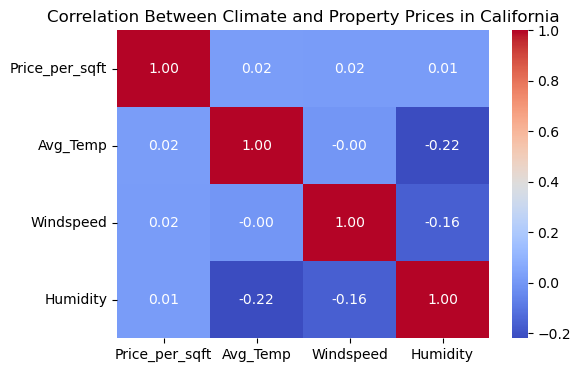

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
final_df = pd.read_csv("final_dataset_redfins.csv")

# Step 1: Calculate Property Price per Square Foot
final_df["Price_per_sqft"] = final_df["Price"] / final_df["Sqft"]

# Step 2: Compute correlation matrix between climate variables and property prices
correlation_matrix = final_df[["Price_per_sqft", "Avg_Temp", "Windspeed", "Humidity"]].corr()

# Step 3: Visualize correlation using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Climate and Property Prices in California")
plt.show()

### **ANALYSIS - 2**
**Are homes in coastal cities like Los Angeles or San Francisco more expensive due to 
their mild climate, compared to inland areas like Sacramento or Palm Springs?**

**Yes**, the analysis reveals a significant disparity between property prices in **coastal** and **inland** regions of California, with coastal cities averaging **$684.08** per square foot.

While inland  cities  have  a  much  lower  average  of **$302.36** per square foot. Climate conditions also show notable differences, as coastal cities experience **slightly cooler temperatures (58.82°F)** and **lower wind speeds (12.48 mph)** compared to inland areas, which have an **average temperature of 59.17°F** and **higher wind speeds of 12.93 mph**. The findings suggest that **location, particularly proximity to the coast, plays a critical role in real estate valuation**, with coastal properties commanding significantly higher prices despite relatively minor differences in climate conditions.

C:\Users\ATHISH\AppData\Local\Temp\ipykernel_4308\69566807.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped_prices.index, y=grouped_prices.values, palette=["blue", "orange"])


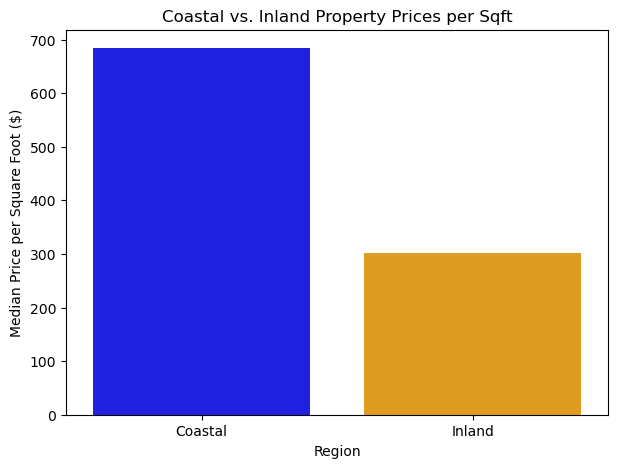


Climate Summary Statistics:
         Avg_Temp  Windspeed
Region                      
Coastal     58.82      12.48
Inland      59.17      12.93

Analysis Summary:
 Median Price per Sqft in Coastal Cities: $684.08
 Median Price per Sqft in Inland Cities: $302.36


In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
final_df = pd.read_csv("final_dataset_redfins.csv")

# Define coastal and inland cities
coastal_cities = ["Los Angeles", "San Francisco", "San Diego", "Santa Cruz", "Monterey"]
inland_cities = ["Sacramento", "Palm Springs", "Fresno", "Bakersfield", "Riverside"]

# Extract coastal and inland properties based on Address
final_df["Region"] = final_df["Address"].apply(lambda x: "Coastal" if any(city in x for city in coastal_cities) 
                                               else ("Inland" if any(city in x for city in inland_cities) else "Other"))

# Filter only Coastal and Inland properties
filtered_df = final_df[final_df["Region"].isin(["Coastal", "Inland"])]

# Calculate median property price per square foot for both regions
grouped_prices = filtered_df.groupby("Region")["Price_per_sqft"].median()

# Calculate median climate conditions (Avg_Temp and Windspeed)
grouped_climate = filtered_df.groupby("Region")[["Avg_Temp", "Windspeed"]].median()


# **Step 1: Create Bar Graph Comparing Property Prices per Square Foot**
plt.figure(figsize=(7, 5))
sns.barplot(x=grouped_prices.index, y=grouped_prices.values, palette=["blue", "orange"])
plt.xlabel("Region")
plt.ylabel("Median Price per Square Foot ($)")
plt.title("Coastal vs. Inland Property Prices per Sqft")
plt.show()


# **Step 2: Display Climate Condition Differences**
print("\nClimate Summary Statistics:")
print(grouped_climate)

# **Step 3: Generate Summary Report**
print("\nAnalysis Summary:")
print(f" Median Price per Sqft in Coastal Cities: ${grouped_prices['Coastal']:.2f}")
print(f" Median Price per Sqft in Inland Cities: ${grouped_prices['Inland']:.2f}")

### **ANALYSIS - 3**
**Does climate variability, such as extreme temperatures or high wind speeds, lower home prices or influence housing demand in certain areas?**

**RESULTS**

**Yes**, the analysis suggests that **extreme climate conditions**, particularly **high temperatures** and **high wind speeds**, may negatively influence **property valuation**, as evidenced by the **lower average price per square foot ($307.51)**

In areas with these combined extremes compared to areas with **normal climate conditions ($2708.08)**. 

The **scatter plots** reveal a **broad dispersion of property prices** across all climate ranges, indicating that while **extreme conditions may exert downward pressure** on prices, **other factors not captured in this analysis** also significantly contribute to **property valuation and housing demand**.


Mean Property Prices per Square Foot Across Extreme Climate Conditions:
Extreme_Temp  Extreme_Windspeed
High          High                  307.514590
              Low                   253.238859
              Normal                480.091718
Low           High                  287.557800
              Low                   380.783957
              Normal                421.734301
Normal        High                  319.724129
              Low                   642.255373
              Normal               2708.077909
Name: Price_per_sqft, dtype: float64


C:\Users\ATHISH\AppData\Local\Temp\ipykernel_4308\690149510.py:42: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(x=filtered_df["Avg_Temp"], y=filtered_df["Price_per_sqft"], hue=filtered_df["Extreme_Temp"], palette=["blue", "orange", "red"])


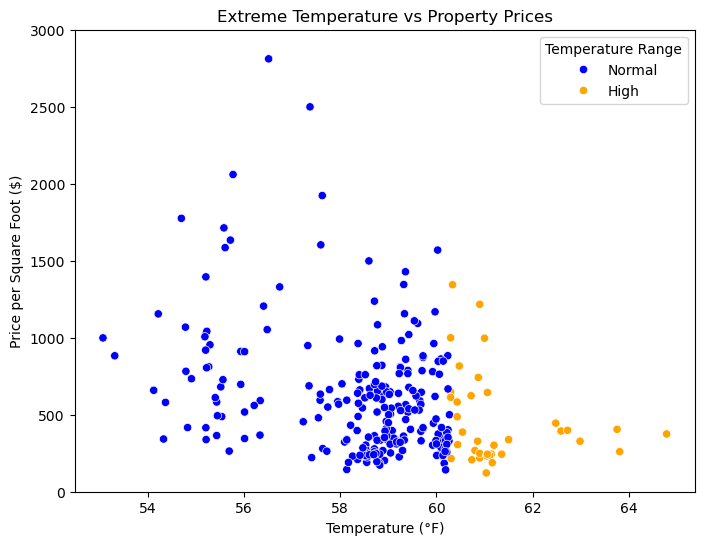

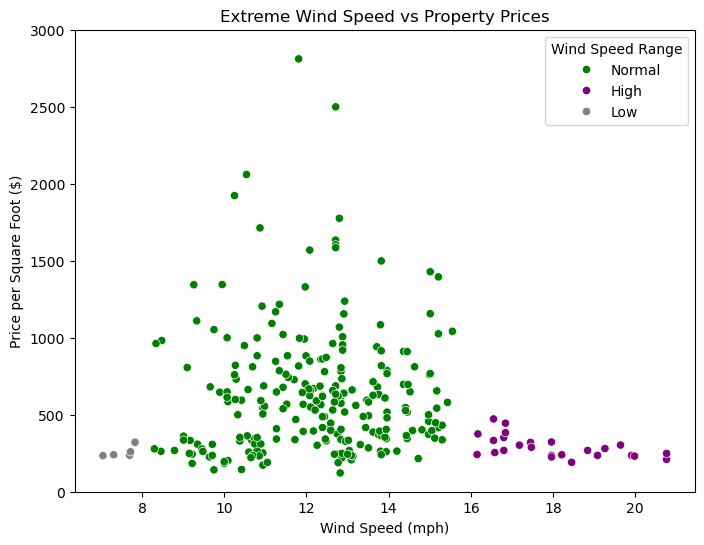

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
final_df = pd.read_csv("final_dataset_redfins.csv")

# Step 1: Define Coastal and Inland Cities
coastal_cities = ["Los Angeles", "San Francisco", "San Diego", "Santa Cruz", "Monterey"]
inland_cities = ["Sacramento", "Palm Springs", "Fresno", "Bakersfield", "Riverside"]

# Label regions based on Address
final_df["Region"] = final_df["Address"].apply(lambda x: "Coastal" if any(city in x for city in coastal_cities) 
                                               else ("Inland" if any(city in x for city in inland_cities) else "Other"))

# Filter only Coastal and Inland properties
filtered_df = final_df[final_df["Region"].isin(["Coastal", "Inland"])]

# Step 2: Define Extreme High & Low Conditions
extreme_temp_low = final_df["Avg_Temp"].quantile(0.10)  # Bottom 10% (coldest areas)
extreme_temp_high = final_df["Avg_Temp"].quantile(0.90) # Top 10% (hottest areas)
extreme_wind_low = final_df["Windspeed"].quantile(0.10) # Bottom 10% (least windy areas)
extreme_wind_high = final_df["Windspeed"].quantile(0.90) # Top 10% (windiest areas)

# Create labels for extreme climate conditions
final_df["Extreme_Temp"] = final_df["Avg_Temp"].apply(lambda x: "Low" if x <= extreme_temp_low 
                                                       else ("High" if x >= extreme_temp_high else "Normal"))
final_df["Extreme_Windspeed"] = final_df["Windspeed"].apply(lambda x: "Low" if x <= extreme_wind_low 
                                                             else ("High" if x >= extreme_wind_high else "Normal"))

# Ensure filtered_df contains the extreme classifications
filtered_df = final_df[final_df["Region"].isin(["Coastal", "Inland"])]

# Step 3: Compute Mean Prices per Square Foot for Climate Categories
climate_price_df = final_df.groupby(["Extreme_Temp", "Extreme_Windspeed"])["Price_per_sqft"].mean()

print("\nMean Property Prices per Square Foot Across Extreme Climate Conditions:")
print(climate_price_df)

# Step 4: Scatter Plots - Climate Variability vs. Property Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x=filtered_df["Avg_Temp"], y=filtered_df["Price_per_sqft"], hue=filtered_df["Extreme_Temp"], palette=["blue", "orange", "red"])
plt.ylim(0, 3000)
plt.xlabel("Temperature (°F)")
plt.ylabel("Price per Square Foot ($)")
plt.title("Extreme Temperature vs Property Prices")
plt.legend(title="Temperature Range")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=filtered_df["Windspeed"], y=filtered_df["Price_per_sqft"], hue=filtered_df["Extreme_Windspeed"], palette=["green", "purple", "gray"])
plt.ylim(0, 3000)
plt.xlabel("Wind Speed (mph)")
plt.ylabel("Price per Square Foot ($)")
plt.title("Extreme Wind Speed vs Property Prices")
plt.legend(title="Wind Speed Range")
plt.show()

### **ANALYSIS - 4**
**Does latitude influence property prices, after controlling for climate variables like temperature and humidity?**

**RESULTS**

**Yes**, the **bar graph** above shows that **median property prices per square foot are highest in the 32–34°N and 36–38°N latitude bands**, indicating that certain geographic zones-likely major urban and coastal areas-command a significant price premium.

The **correlation heatmap** reveals that the overall relationship between latitude and property prices is **very weak (correlation = -0.03)**. Similarly, **average temperature and humidity also show negligible correlations with property prices**.
These findings suggest that **other factors-such as local economic demand, neighborhood reputation, and amenities-are much more influential** in determining real estate prices across California than latitude or climate conditions alone.


C:\Users\ATHISH\AppData\Local\Temp\ipykernel_4308\3917081223.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lat_price_df.index, y=lat_price_df["Price_per_sqft"], palette="coolwarm")


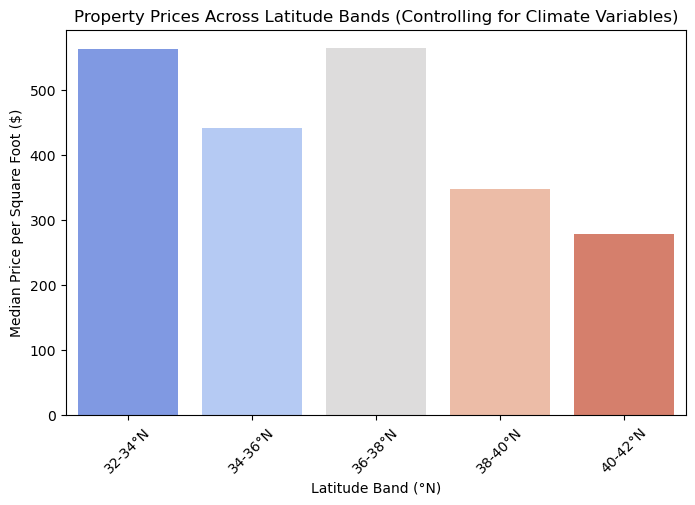

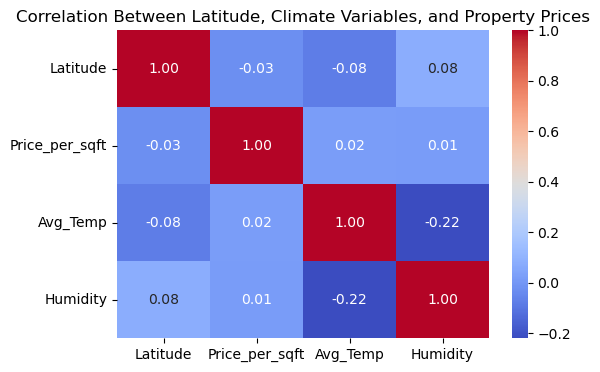

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
final_df = pd.read_csv("final_dataset_redfins.csv")

# Step 1: Create Latitude Bands (Grouped into 2-degree intervals)
final_df["Latitude_Band"] = final_df["Latitude"].apply(lambda x: f"{int(x//2*2)}-{int((x//2+1)*2)}°N")

# Step 2: Compute Mean Prices per Square Foot per Latitude Band
lat_price_df = final_df.groupby("Latitude_Band")[["Price_per_sqft", "Avg_Temp", "Humidity"]].median()

# Step 3: Visualize Trends with Bar Graph (Price per Sqft by Latitude Band)
plt.figure(figsize=(8, 5))
sns.barplot(x=lat_price_df.index, y=lat_price_df["Price_per_sqft"], palette="coolwarm")
plt.xlabel("Latitude Band (°N)")
plt.ylabel("Median Price per Square Foot ($)")
plt.title("Property Prices Across Latitude Bands (Controlling for Climate Variables)")
plt.xticks(rotation=45)
plt.show()

# Step 4: Compute Correlation Between Latitude, Property Prices, Temperature, and Humidity
correlation_matrix = final_df[["Latitude", "Price_per_sqft", "Avg_Temp", "Humidity"]].corr()

# Visualizing Correlation as a Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Latitude, Climate Variables, and Property Prices")
plt.show()